# Random Forest vs Bagging

## Core Idea

- Random Forest is a **special case of Bagging**
- But they are **not exactly the same**

---

## Bagging (Bootstrap Aggregation)

- Can use **any base model**:
  - Decision Tree  
  - KNN  
  - SVM  

- Default in scikit-learn:
  - If no base estimator is provided → Decision Tree is used  

---

## Important Question

### If we use Decision Trees in Bagging, does it become Random Forest?

**Answer: NO**

Even if all base models are Decision Trees, it is still **not Random Forest**

---

## Key Difference

The major difference lies in **Feature Sampling (Column Sampling)**

---

## Feature Sampling Comparison

| Aspect | Bagging | Random Forest |
|--------|--------|--------------|
| Base Models | Any (DT, KNN, SVM) | Only Decision Trees |
| Row Sampling | Yes (Bootstrap) | Yes (Bootstrap) |
| Feature Sampling | Optional | Mandatory |
| Sampling Level | Tree Level | Node Level |
| Randomness | Less | More |
| Diversity Between Trees | Moderate | High |

---


## Setup 1 vs Setup 2 (Feature Sampling)

### Setup 1: Bagging (Tree-Level Sampling)

- A subset of features is selected **once per tree**
- The same selected features are used for **all splits in that tree**

#### Example:
- Tree 1 → (col1, col3)
- Tree 2 → (col2, col5)


- Feature set is **fixed for the entire tree**

👉 Called **Tree-Level Feature Sampling**

---

### Setup 2: Random Forest (Node-Level Sampling)

- A subset of features is selected **at every split (node)**
- Different nodes can use **different feature subsets**

#### Example:
- Node 1 → (col1, col3)
- Node 2 → (col2, col5)
- Node 3 → (col1, col4)


- Feature selection is **dynamic and changes at each node**

👉 Called **Node-Level Feature Sampling**

---

## Key Difference

- Bagging → Same features throughout a tree  
- Random Forest → Different features at every split  

👉 This extra randomness makes Random Forest more powerful

## code example 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    random_state=42
)

feature_names = ['f1','f2','f3','f4','f5']
X = pd.DataFrame(X, columns=feature_names)

In [10]:
X

,f1,f2,f3,f4,f5
0,0.890689,-1.194702,0.278035,1.378671,0.483691
1,0.493646,1.711875,0.714784,1.359915,-0.303170
2,0.286973,-3.534690,3.338576,-1.973863,3.859960
3,1.238156,1.230387,-0.688262,-0.697273,-0.431156
4,-2.841144,1.317607,1.233736,0.155138,2.306480
...,...,...,...,...,...
195,-1.615186,0.293621,0.749842,0.555855,-0.998435
196,0.337572,-0.543159,-1.070960,5.373376,-1.762125
197,-2.060478,0.542349,0.656212,0.566863,2.826974
198,-1.404885,-1.147434,-0.217369,-0.245550,1.051754


#### bagging model [setup 1]

In [11]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=3,
    max_features=2,     # select 2 features per tree
    bootstrap_features=True,
    random_state=42
)

bag.fit(X, y)

,estimator,DecisionTreeClassifier()
,n_estimators,3
,max_samples,1.0
,max_features,2
,bootstrap,True
,bootstrap_features,True
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [12]:
for i, features in enumerate(bag.estimators_features_):
    print(f"Tree {i+1} uses features:", X.columns[features].tolist())

Tree 1 uses features: ['f4', 'f2']
Tree 2 uses features: ['f4', 'f4']
Tree 3 uses features: ['f1', 'f2']


#### Setup 2: Random Forest (Node-Level Sampling)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=1,      # single tree for clarity
    max_features=2,      # features per split
    random_state=42
)

rf.fit(X, y)

,n_estimators,1
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
tree = rf.estimators_[0].tree_

# Get feature indices used at each node
features_used = tree.feature

# Map to names
used_features = [feature_names[i] for i in features_used if i != -2]

print("Features used across nodes:", used_features)

Features used across nodes: ['f3', 'f2', 'f3', 'f4', 'f3', 'f5', 'f5', 'f3', 'f2', 'f3', 'f4', 'f2', 'f1', 'f1', 'f3', 'f5', 'f4', 'f1', 'f3', 'f4', 'f4', 'f2', 'f1', 'f1', 'f5', 'f2', 'f4', 'f2']


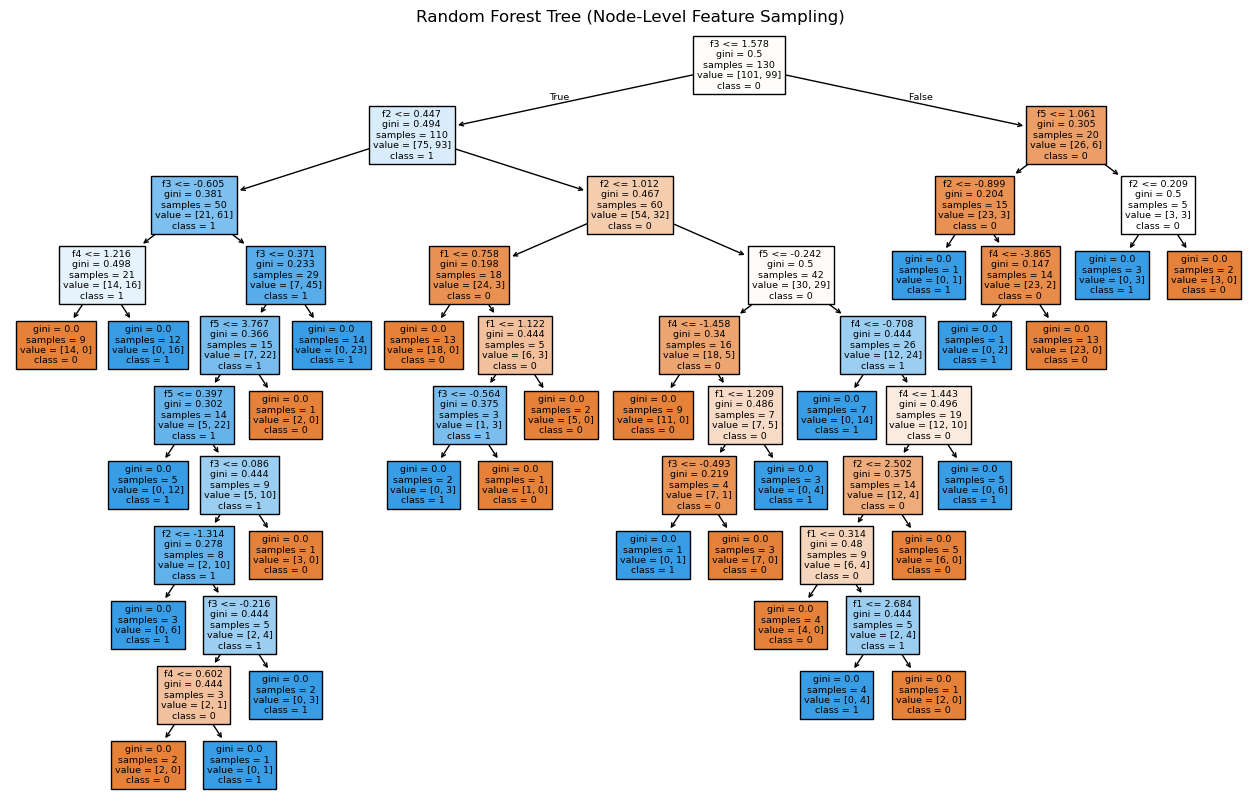

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['0','1'],
    filled=True
)

plt.title("Random Forest Tree (Node-Level Feature Sampling)")
plt.show()

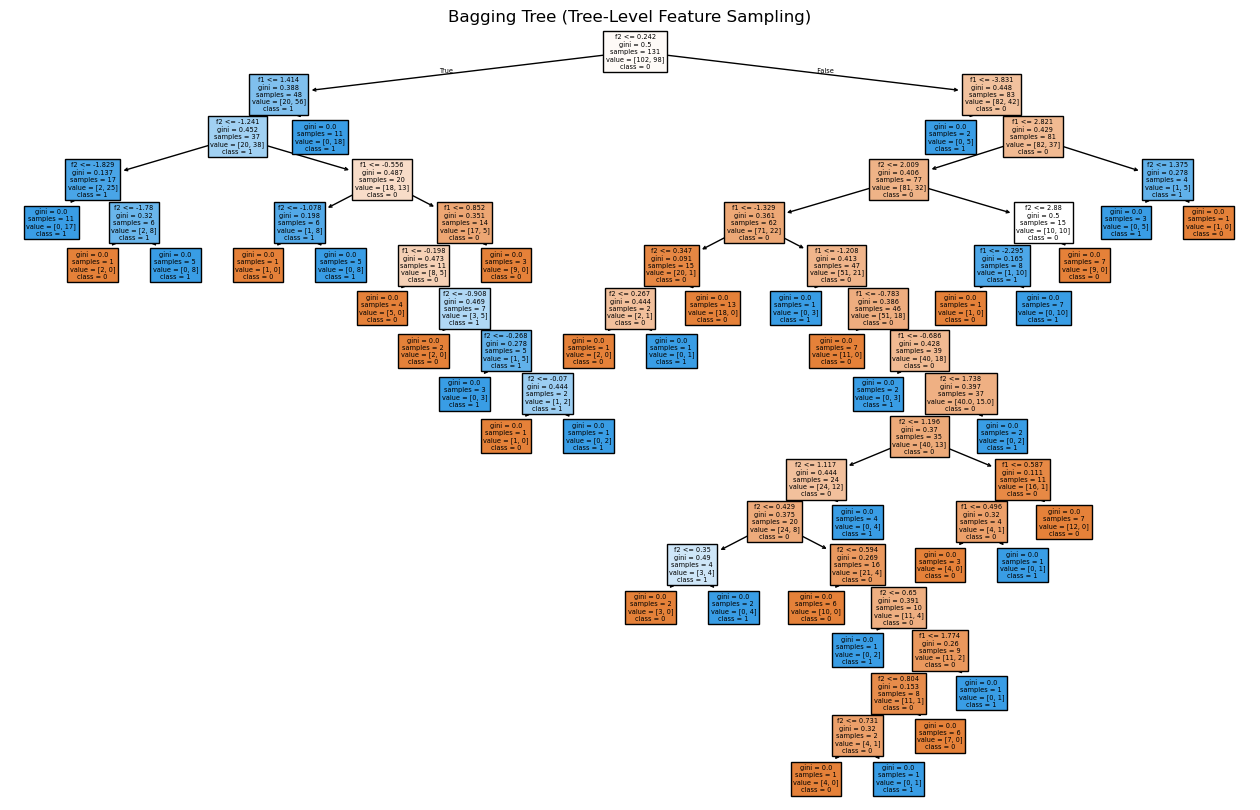

In [16]:
plt.figure(figsize=(16, 10))

plot_tree(
    bag.estimators_[0],
    feature_names=X.columns,
    class_names=['0','1'],
    filled=True
)

plt.title("Bagging Tree (Tree-Level Feature Sampling)")
plt.show()

> so most of the time random forest beats bagging 